# CIFAR10 Model Comparison: S4 vs LMU on Test Set

This notebook compares S4, LMU models on the CIFAR10 dataset test set across different training data fractions.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

compare_folder = Path("figs")
compare_folder.mkdir(exist_ok=True)

print("Imports successful")

Imports successful


## 1. Load CIFAR10 Experiment Results

Load all S4, LMU results (including test metrics) across different data fractions.


In [2]:
from src.eval.compare import load_all_experiments

base_dir = "./runs"
models = ['s4', 'lmu', 'mamba']
fractions = [0.1, 0.25, 0.5, 1.0]
task_name = "cifar10"

print("="*60)
print("LOADING CIFAR10 EXPERIMENT RESULTS")
print("="*60)
print()

all_results = load_all_experiments(
    base_dir=base_dir,
    models=models,
    fractions=fractions,
    task_name=task_name
)

print()
print("="*60)
print("LOADING COMPLETE")
print("="*60)

# Quick summary
for model in models:
    n_loaded = sum(1 for results in all_results[model].values() if results)
    print(f"{model.upper()}: Loaded {n_loaded}/{len(fractions)} experiments")

CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


LOADING CIFAR10 EXPERIMENT RESULTS

Loading S4 @ 10%: cifar10_s4_task_frac_10
Loading S4 @ 25%: cifar10_s4_task_frac_25
Loading S4 @ 50%: cifar10_s4_task_frac_50
Loading S4 @ 100%: cifar10_s4_task_equal_params
Loading LMU @ 10%: cifar10_lmu_task_frac_10
Loading LMU @ 25%: cifar10_lmu_task_frac_25
Loading LMU @ 50%: cifar10_lmu_task_frac_50
Loading LMU @ 100%: cifar10_lmu_task
Loading MAMBA @ 10%: cifar10_mamba_task_frac_10
Loading MAMBA @ 25%: cifar10_mamba_task_frac_25
Loading MAMBA @ 50%: cifar10_mamba_task_frac_50
Loading MAMBA @ 100%: cifar10_mamba_task

LOADING COMPLETE
S4: Loaded 4/4 experiments
LMU: Loaded 4/4 experiments
MAMBA: Loaded 4/4 experiments


## 2. Test Metrics Comparison Table

Summary table of test set performance for all experiments.

In [3]:
from src.eval.compare import create_test_comparison_table
import pandas as pd

print()

test_comparison_df = create_test_comparison_table(
    all_results,
    metrics=['accuracy', 'loss']
)

pd.options.display.float_format = '{:.4f}'.format

print("="*60)
print("BEST MODEL PER DATA FRACTION")
print("="*60)

for pct in sorted(test_comparison_df['data_pct'].unique()):
    subset = test_comparison_df[test_comparison_df['data_pct'] == pct]
    best_idx = subset['accuracy'].idxmax()
    best_row = subset.loc[best_idx]
    print(f"\n{pct}% data: {best_row['model']} (Accuracy: {best_row['accuracy']:.4f})")

print(test_comparison_df.to_string())


BEST MODEL PER DATA FRACTION

10% data: S4 (Accuracy: 0.5519)

25% data: S4 (Accuracy: 0.6126)

50% data: S4 (Accuracy: 0.6406)

100% data: S4 (Accuracy: 0.7421)
    model  data_pct  accuracy   loss  num_samples
0     LMU        10    0.5069 1.4014        10000
1     LMU        25    0.5545 1.2881        10000
2     LMU        50    0.5958 1.1855        10000
3     LMU       100    0.6493 0.9954        10000
4   MAMBA        10    0.4846 1.4590        10000
5   MAMBA        25    0.5822 1.1960        10000
6   MAMBA        50    0.6394 1.0763        10000
7   MAMBA       100    0.6829 0.9906        10000
8      S4        10    0.5519 1.4658        10000
9      S4        25    0.6126 1.4473        10000
10     S4        50    0.6406 1.0889        10000
11     S4       100    0.7421 0.9779        10000


## 3. Test Accuracy Comparison

Bar chart showing test accuracy for each model and data fraction.


Plot saved to: figs/test_accuracy_comparison.png


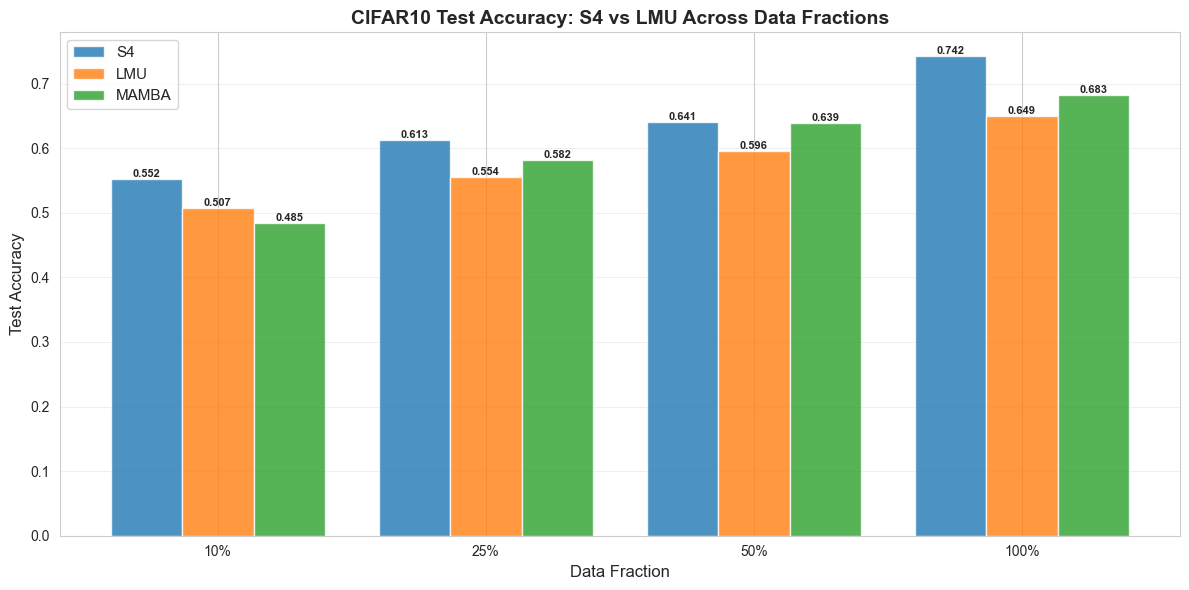

In [4]:
from src.eval.compare import plot_test_metric_comparison

plot_test_metric_comparison(
    all_results,
    metric_key='accuracy',
    title='CIFAR10 Test Accuracy: S4 vs LMU Across Data Fractions',
    ylabel='Test Accuracy',
    save_path=str(compare_folder / 'test_accuracy_comparison.png')
)

## 4. Test Loss Comparison

Bar chart showing test loss for each model and data fraction.


Plot saved to: figs/test_loss_comparison.png


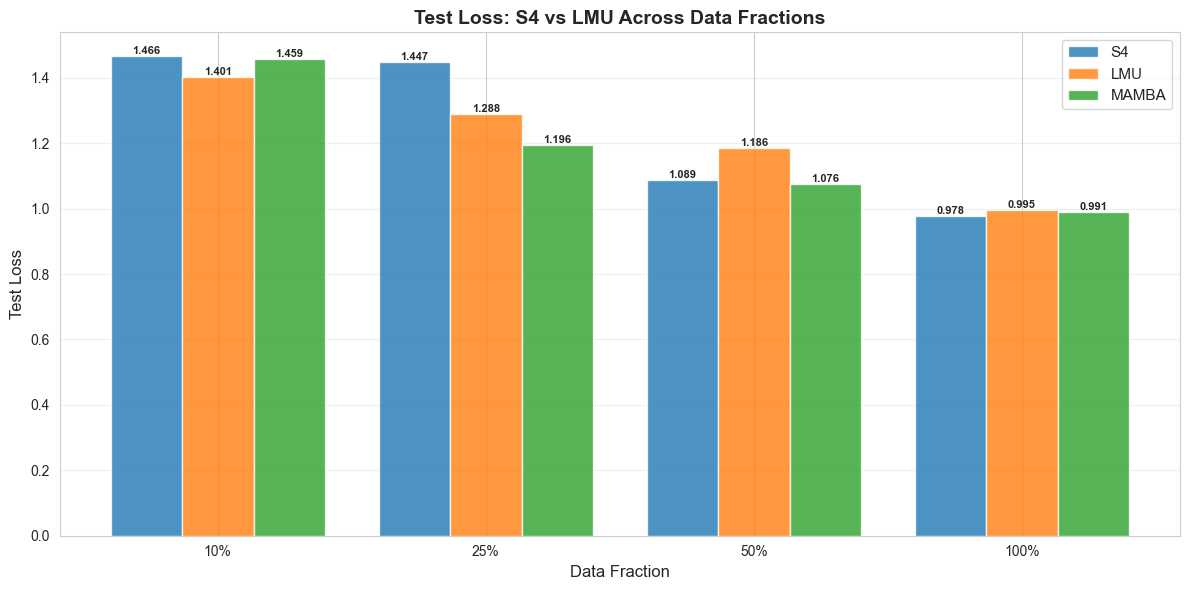

In [5]:
plot_test_metric_comparison(
    all_results,
    metric_key='loss',
    title='Test Loss: S4 vs LMU Across Data Fractions',
    ylabel='Test Loss',
    save_path=str(compare_folder / 'test_loss_comparison.png')
)

## 5. Test Set Data Efficiency

Which model generalizes better with limited training data?


Plot saved to: figs/test_data_efficiency.png


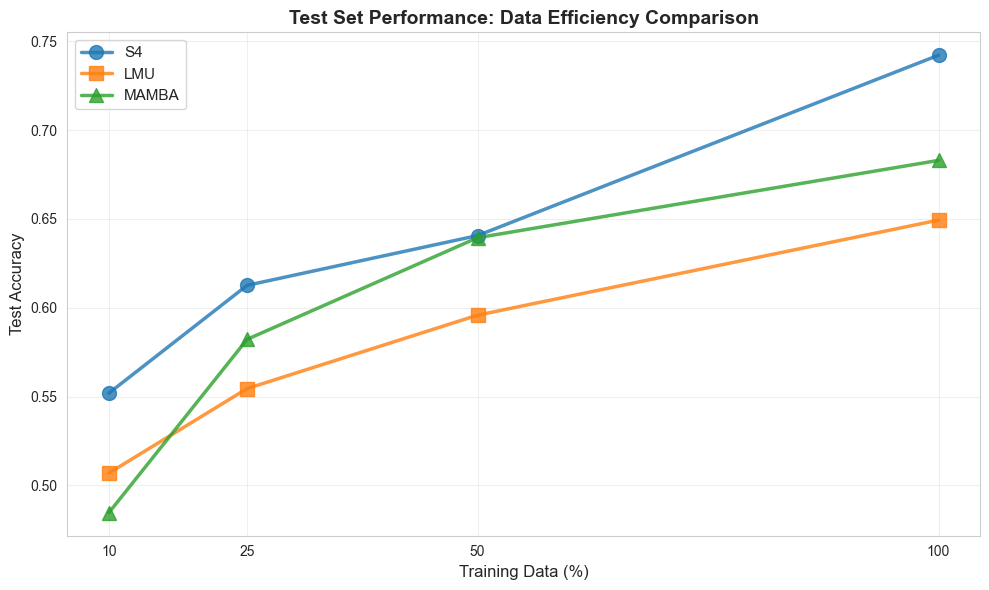

In [6]:
from src.eval.compare import plot_test_data_efficiency

plot_test_data_efficiency(
    all_results,
    metric_key='accuracy',
    ylabel='Test Accuracy',
    save_path=str(compare_folder / 'test_data_efficiency.png')
)

## 6. Test Performance Heatmaps

Visual comparison of test set performance across models and data fractions.


Plot saved to: figs/test_performance_heatmap.png


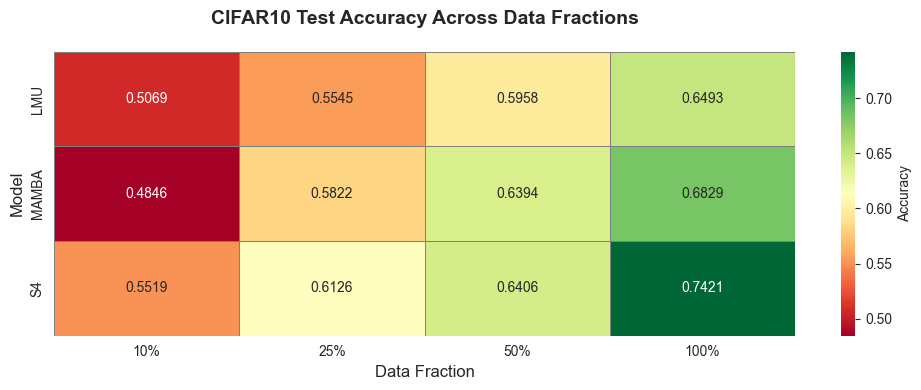

In [7]:
from src.eval.compare import plot_performance_heatmap

plot_performance_heatmap(
    all_results,
    metric_key='accuracy',
    title='CIFAR10 Test Accuracy Across Data Fractions',
    annot_format='.4f',
    save_path=str(compare_folder / 'test_performance_heatmap.png')
)

## 8. Per-Class Accuracy Heatmap

Visualize per-class accuracies across all models and data fractions.


Plot saved to: figs/per_class_accuracy_heatmap.png


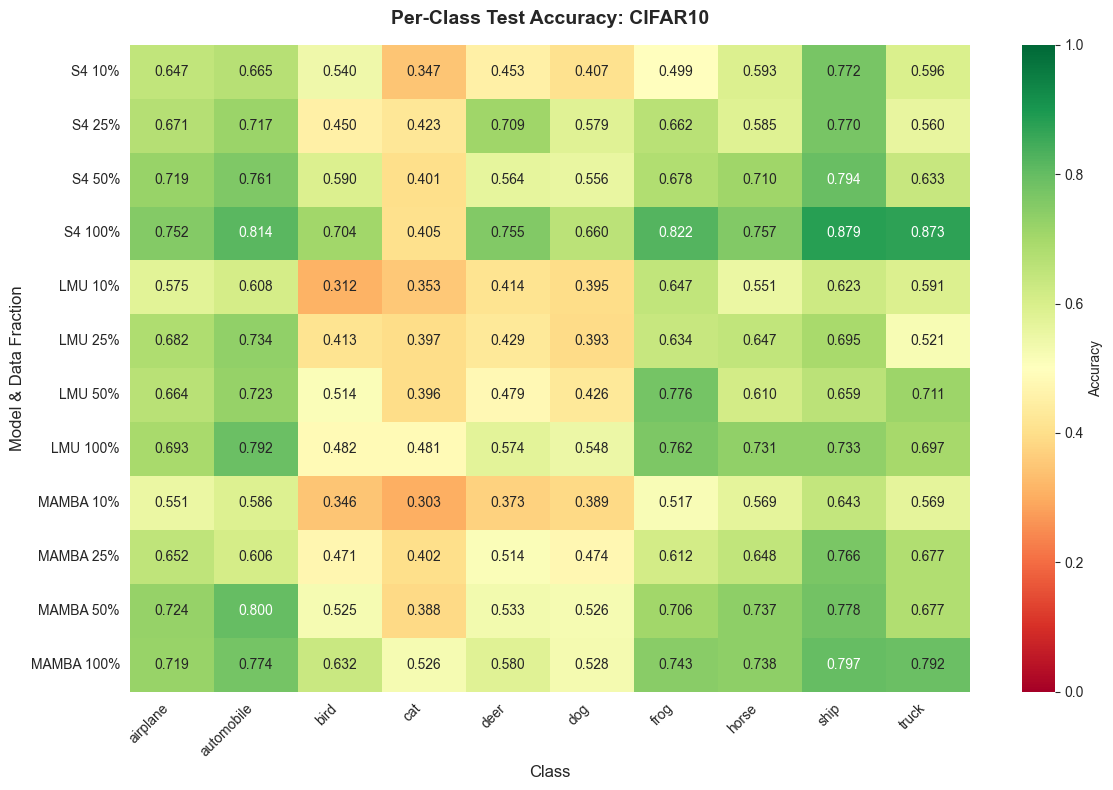

In [8]:
import numpy as np

def plot_per_class_accuracy_heatmap(all_results, models, fractions):
    """Create a heatmap showing per-class accuracies."""

    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

    # Prepare data
    data = []
    row_labels = []

    for model in models:
        for frac in fractions:
            if frac in all_results[model] and all_results[model][frac]:
                results = all_results[model][frac]
                per_class_acc = results.get('per_class_accuracy', {})

                if per_class_acc:
                    accs = [per_class_acc.get(f"class_{i:02d}", 0) for i in range(10)]
                    data.append(accs)
                    row_labels.append(f"{model.upper()} {frac*100:.0f}%")

    if not data:
        print("No per-class accuracy data available")
        return

    # Create heatmap
    data_array = np.array(data)

    plt.figure(figsize=(12, 8))
    sns.heatmap(data_array,
                xticklabels=class_names,
                yticklabels=row_labels,
                annot=True,
                fmt='.3f',
                cmap='RdYlGn',
                vmin=0.0,
                vmax=1.0,
                cbar_kws={'label': 'Accuracy'})

    plt.title('Per-Class Test Accuracy: CIFAR10', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Class', fontsize=12)
    plt.ylabel('Model & Data Fraction', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # Save the plot
    save_path = compare_folder / 'per_class_accuracy_heatmap.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved to: {save_path}")

    plt.show()

plot_per_class_accuracy_heatmap(all_results, models, fractions)

